In [3]:
# Load libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [5]:
# Load Dataset
PATH = r'D:\Project code\financial-crime-ai\data\creditcard.csv'
data = pd.read_csv(PATH)

print(data.shape)
data.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Fraud Distribution
fraud_counts = data['Class'].value_counts()
print(fraud_counts)

Class
0    284315
1       492
Name: count, dtype: int64


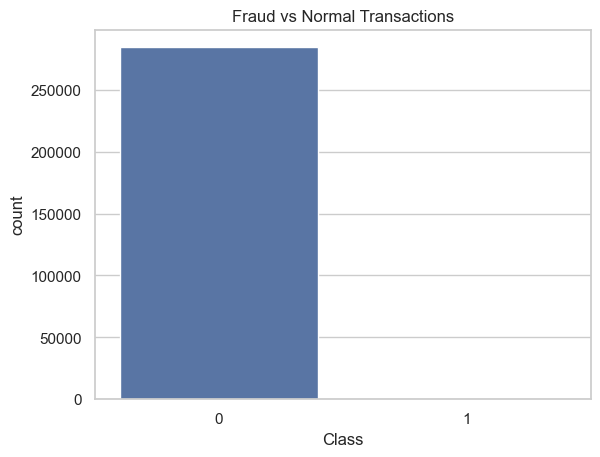

In [8]:
sns.countplot(x='Class',data=data)
plt.title('Fraud vs Normal Transactions')
plt.show()

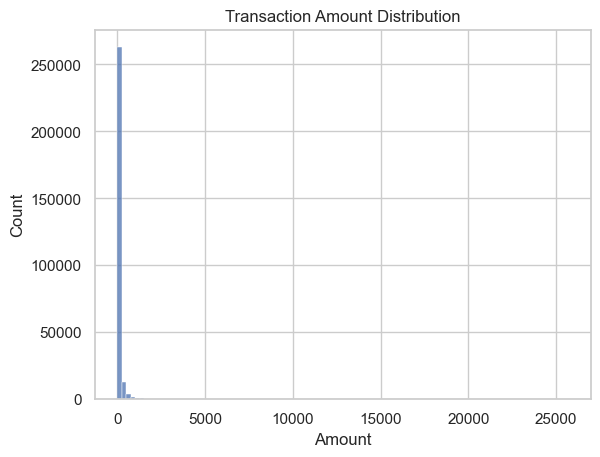

In [9]:
# Transactions amount Analysis
plt.Figure(figsize=(10,7))
sns.histplot(data['Amount'],bins=100)
plt.title("Transaction Amount Distribution")
plt.show()

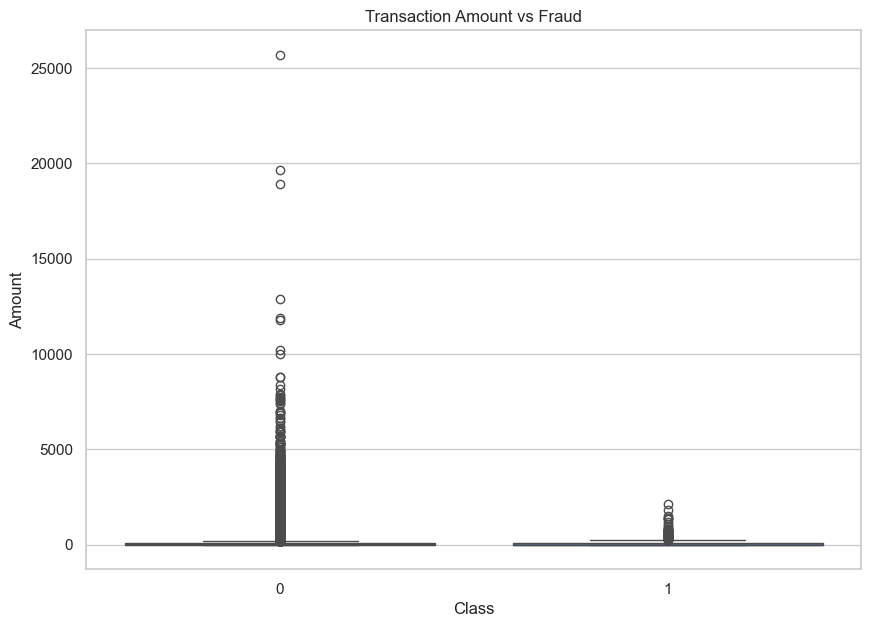

In [11]:
plt.figure(figsize=(10,7))

sns.boxplot(x='Class', y='Amount', data=data)

plt.title("Transaction Amount vs Fraud")
plt.show()

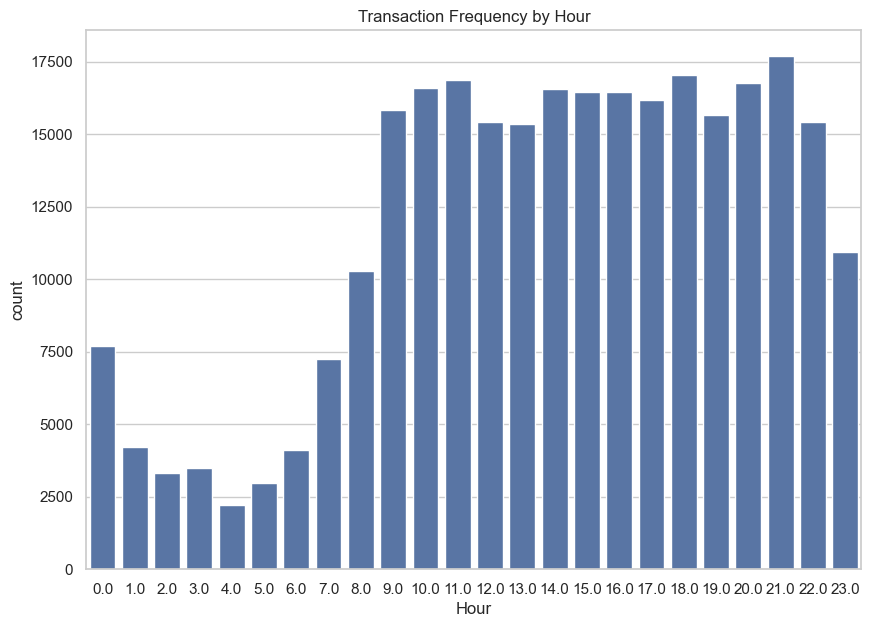

In [13]:
# Time Behavior Analysis
# Plot transactions per hour
data['Hour'] = (data['Time'] // 3600) % 24
plt.figure(figsize=(10,7))

sns.countplot(x='Hour', data=data)

plt.title("Transaction Frequency by Hour")
plt.show()

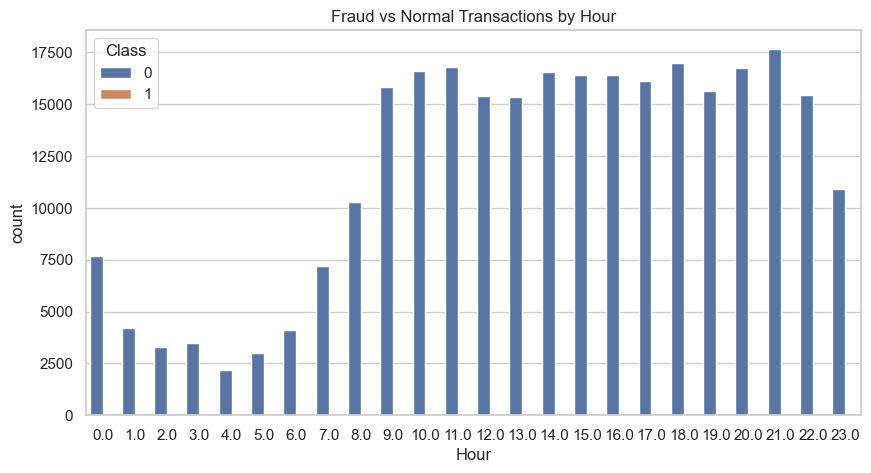

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(x='Hour', hue='Class', data=data)

plt.title("Fraud vs Normal Transactions by Hour")
plt.show()

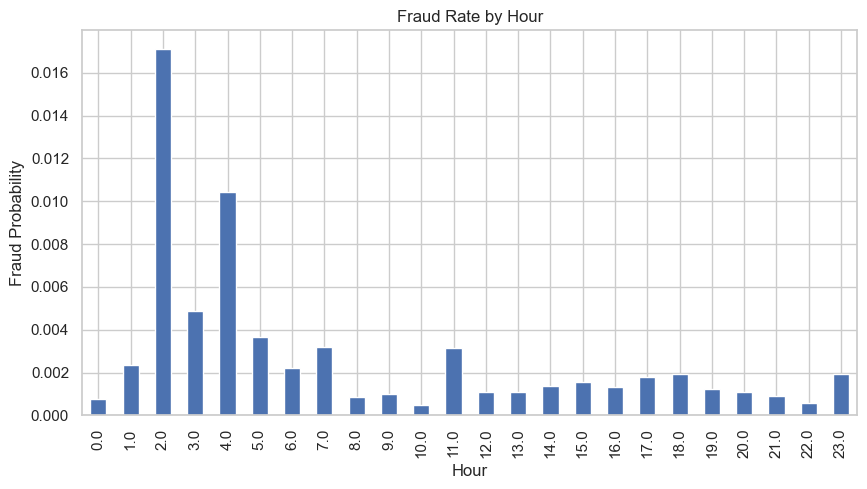

In [18]:
fraud_by_hour = data.groupby('Hour')['Class'].mean()

plt.figure(figsize=(10,5))
fraud_by_hour.plot(kind='bar')

plt.title("Fraud Rate by Hour")
plt.ylabel("Fraud Probability")
plt.show()

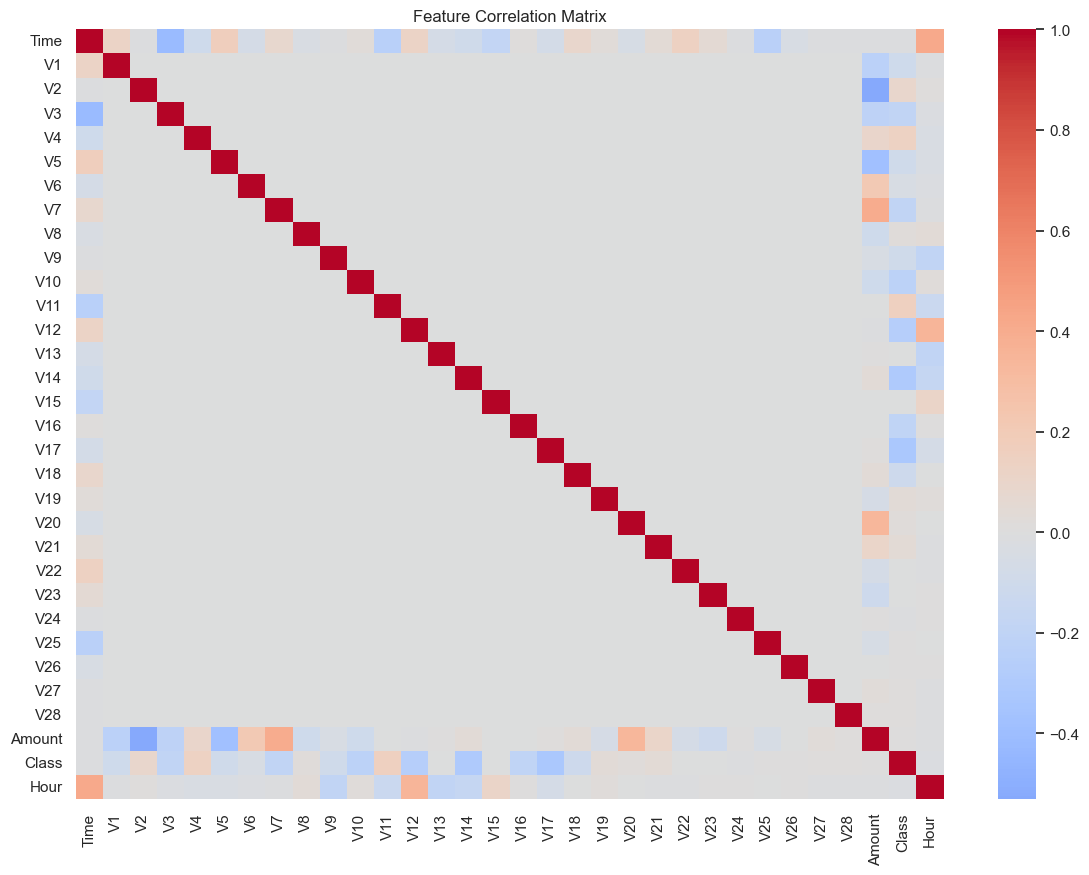

In [15]:
# Correlation Analysis
corr = data.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Feature Correlation Matrix")
plt.show()

In [16]:
# Top correlated variables
fraud_corr = corr['Class'].sort_values(ascending=False)

print(fraud_corr.head(10))

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64


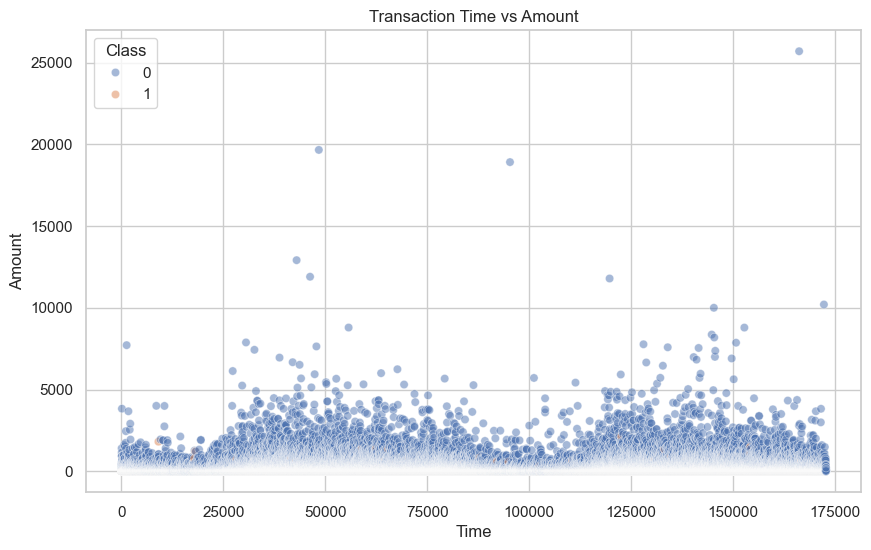

In [17]:
# Fraud Amount vs Time
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=data['Time'],
    y=data['Amount'],
    hue=data['Class'],
    alpha=0.5
)

plt.title("Transaction Time vs Amount")
plt.show()

### Key Insights

1. Fraud transactions are extremely rare (~0.17%).
2. Transaction amounts are highly skewed with many small values.
3. Fraud does not necessarily involve high-value transactions.
4. Several PCA components (V11, V4, V2) correlate with fraud activity.
5. Due to heavy class imbalance, fraud patterns must be analyzed using rates rather than counts.
